# DQN with Acrobot-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `Acrobot-v1` using the Gymnassium API for envrionment.

Acrobot has a `Box(6,)` **observation space** and a `Discrete(3)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [1]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the `config` file

In [2]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_acrobot_2', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'Acrobot-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': []}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 10000,
  'batch_size': 128,
  'nn_learning_rate': 0.0003,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99995,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1,
  'gd_steps_ceil': 1,
  'grad_clip_norm': 20.0},
 'training': {'no_episodes': 500,
  'target_network_update_steps': 2,
  'train_frequency_steps': 2,
  'use_episode_training': False,
  'solved_reward': -80,
  'warmup_steps': 5000,
  'early_stopping_patience_eps': 50,
  'no_eps_to_avg': 10},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout',
    'kwargs': {'seed': 52},
    'outputs': ['Hankel Q', 'Hankel V']},
   {'name': 'q_matrix_dqn',
    'kwargs': {'state_discre

## Creating the Envrionment

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 6 n_actions: 3


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
    grad_clip_norm=a["grad_clip_norm"],
)

## Analysis (Low Rank)

In [6]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs, outputs}. Resolve `name` to its callable,
# pre-bind config-supplied `kwargs` with functools.partial, and pair it with the
# list of output names so the training loop knows how many matrices to expect.
analysis["methods"] = [
    (partial(analysis_methods[m["name"]], **m.get("kwargs", {})), m["outputs"]) # Lookup partial but it passes in the arguments mentioned in the config to the 
    # required functions automatically 
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [(functools.partial(<function hankel_rollout at 0x11acbba60>, seed=52),
   ['Hankel Q', 'Hankel V']),
  (functools.partial(<function q_matrix_dqn at 0x11acbb920>, state_discretisation=[8, 8, 8, 8, 8, 8], batch_size=64),
   ['Q-function'])]}

## Agent Training 

  0%|          | 0/500 [00:00<?, ?it/s]

episode 0 avg_rewarg: -500.0
****************************Hankel Q****************************


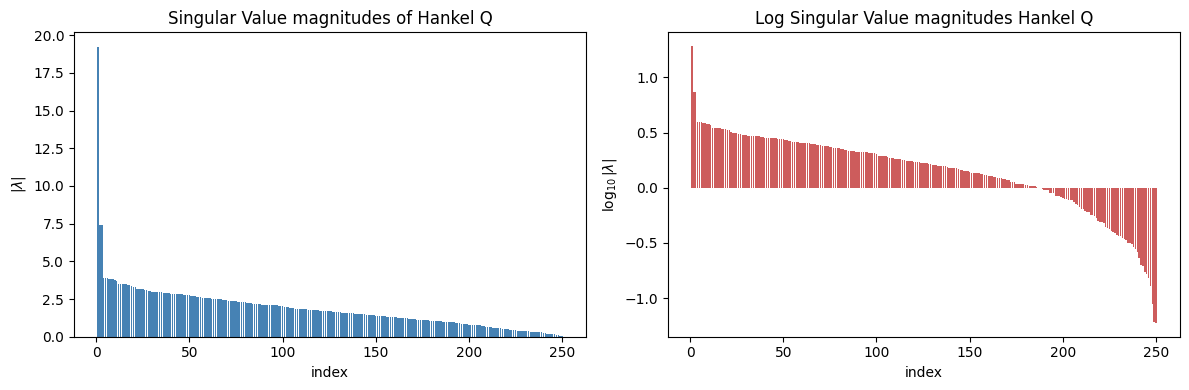

eff_rank: 121, stable_rank: 3.95, spikiness: 3.21, shape: (251, 250), non-zero rows :251, non-zero cols:250
top-r leverage spread: row min=0.003414 max=0.004603 (uniform 0.003984) | col min=0.003399 max=0.004629 (uniform 0.004)
coherence score: row=1.155 col=1.157
****************************Hankel V****************************


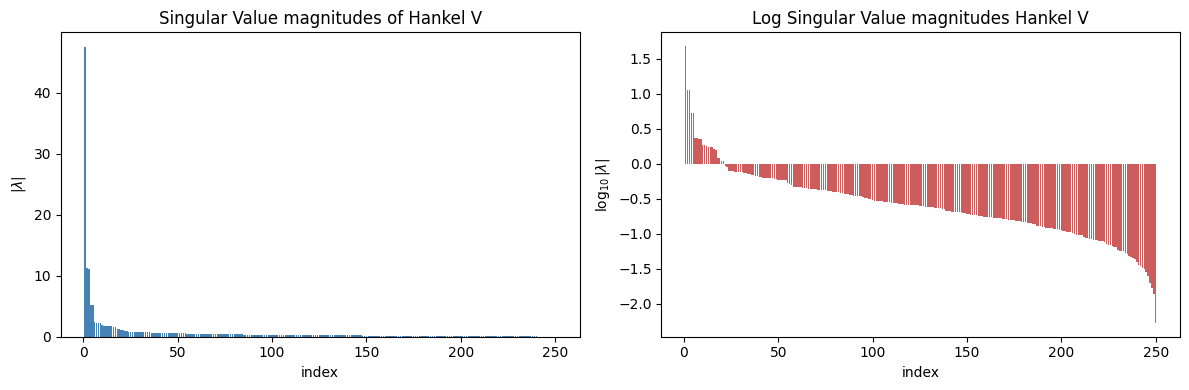

eff_rank: 2, stable_rank: 1.17, spikiness: 2.38, shape: (251, 250), non-zero rows :251, non-zero cols:250
top-r leverage spread: row min=0.0019 max=0.008643 (uniform 0.003984) | col min=0.001862 max=0.008602 (uniform 0.004)
coherence score: row=2.169 col=2.151
****************************Q-function****************************


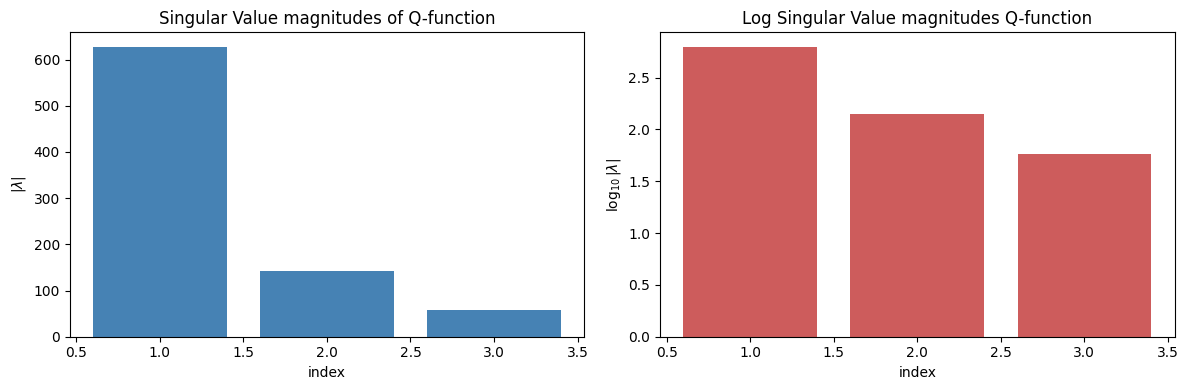

  0%|          | 1/500 [00:09<1:17:34,  9.33s/it]

eff_rank: 1, stable_rank: 1.06, spikiness: 3.28, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=1.458e-17 max=2.778e-05 (uniform 3.815e-06) | col min=0.0689 max=0.4901 (uniform 0.3333)
coherence score: row=7.283 col=1.47


  2%|▏         | 11/500 [00:21<20:43,  2.54s/it] 

episode 10 avg_rewarg: -500.0


  4%|▍         | 21/500 [00:49<20:34,  2.58s/it]

...

episode 30 avg_rewarg: -500.0


  8%|▊         | 41/500 [01:44<20:10,  2.64s/it]

episode 40 avg_rewarg: -440.2


 10%|█         | 50/500 [01:56<10:26,  1.39s/it]

episode 50 avg_rewarg: -269.0
****************************Hankel Q****************************


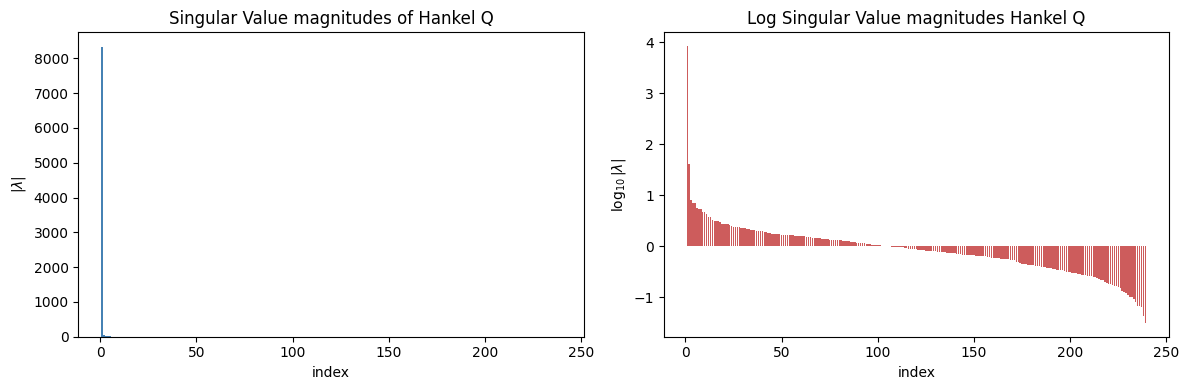

eff_rank: 1, stable_rank: 1.00, spikiness: 1.01, shape: (240, 239), non-zero rows :240, non-zero cols:239
top-r leverage spread: row min=0.004055 max=0.004199 (uniform 0.004167) | col min=0.004072 max=0.004216 (uniform 0.004184)
coherence score: row=1.008 col=1.008
****************************Hankel V****************************


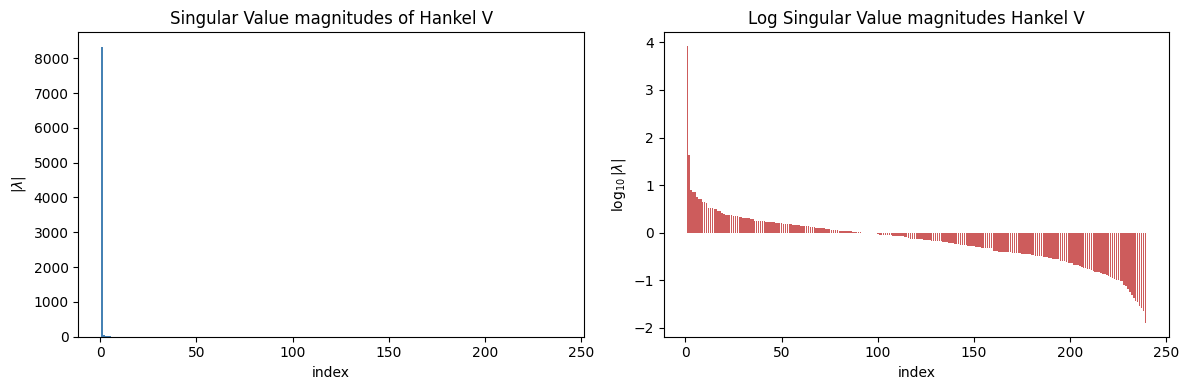

eff_rank: 1, stable_rank: 1.00, spikiness: 1.01, shape: (240, 239), non-zero rows :240, non-zero cols:239
top-r leverage spread: row min=0.004053 max=0.004199 (uniform 0.004167) | col min=0.004071 max=0.004216 (uniform 0.004184)
coherence score: row=1.008 col=1.008
****************************Q-function****************************


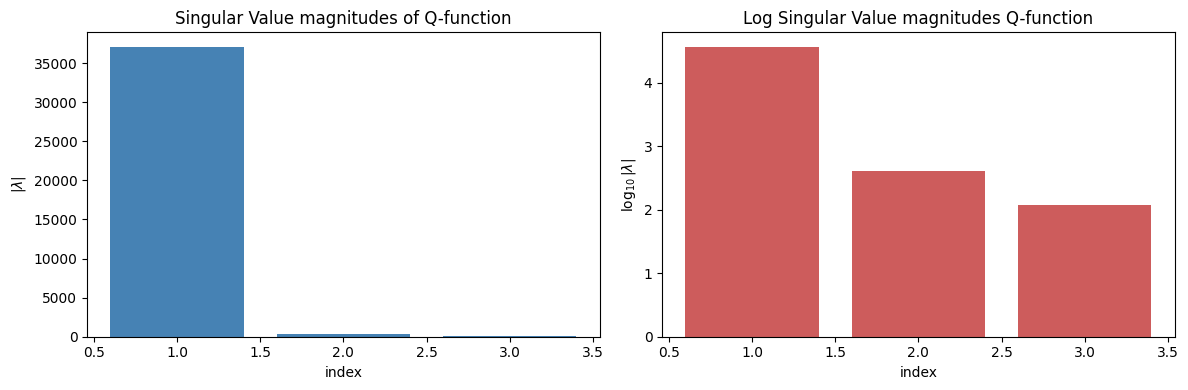

 10%|█         | 51/500 [02:03<23:15,  3.11s/it]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.81, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=5.011e-07 max=1.226e-05 (uniform 3.815e-06) | col min=0.3292 max=0.3395 (uniform 0.3333)
coherence score: row=3.214 col=1.019


 12%|█▏        | 61/500 [02:14<07:28,  1.02s/it]

episode 60 avg_rewarg: -222.3


 14%|█▍        | 71/500 [02:23<05:42,  1.25it/s]

...

episode 80 avg_rewarg: -153.4


 18%|█▊        | 91/500 [02:37<04:22,  1.56it/s]

episode 90 avg_rewarg: -152.5


 20%|██        | 100/500 [02:44<05:15,  1.27it/s]

episode 100 avg_rewarg: -157.1
****************************Hankel Q****************************


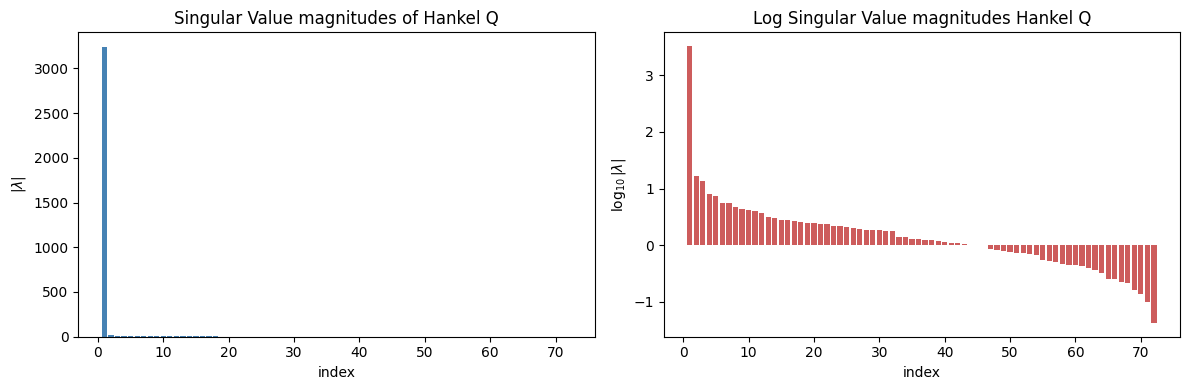

eff_rank: 1, stable_rank: 1.00, spikiness: 1.06, shape: (73, 72), non-zero rows :73, non-zero cols:72
top-r leverage spread: row min=0.01279 max=0.01465 (uniform 0.0137) | col min=0.01297 max=0.01484 (uniform 0.01389)
coherence score: row=1.07 col=1.069
****************************Hankel V****************************


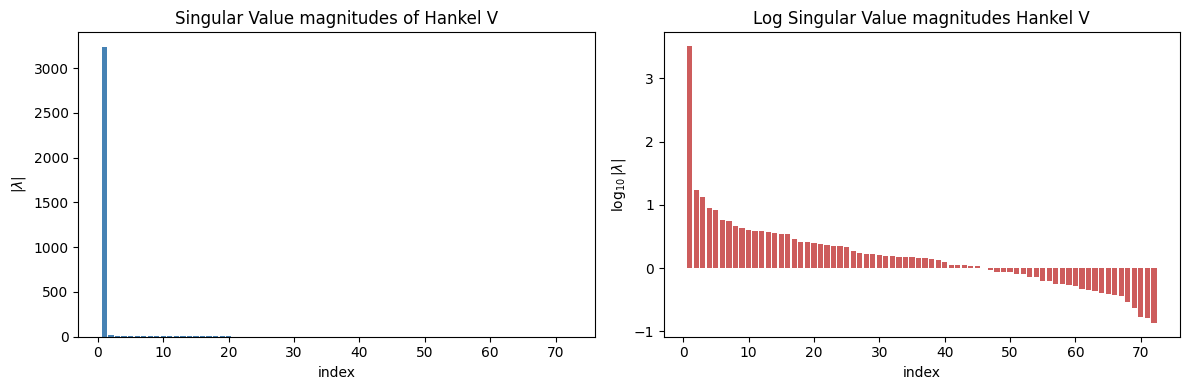

eff_rank: 1, stable_rank: 1.00, spikiness: 1.06, shape: (73, 72), non-zero rows :73, non-zero cols:72
top-r leverage spread: row min=0.01277 max=0.01468 (uniform 0.0137) | col min=0.01296 max=0.01486 (uniform 0.01389)
coherence score: row=1.071 col=1.07
****************************Q-function****************************


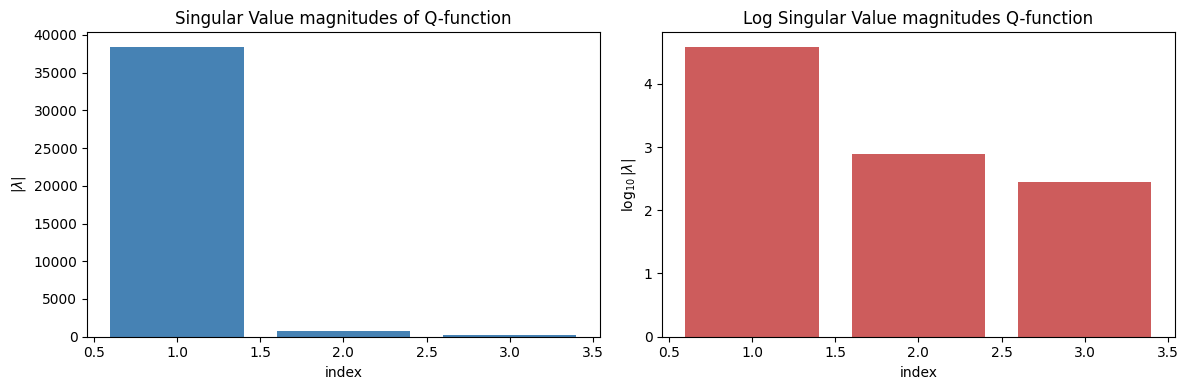

 20%|██        | 101/500 [02:50<14:38,  2.20s/it]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.70, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=2.192e-07 max=1.078e-05 (uniform 3.815e-06) | col min=0.3257 max=0.3404 (uniform 0.3333)
coherence score: row=2.826 col=1.021


 22%|██▏       | 111/500 [02:57<04:46,  1.36it/s]

episode 110 avg_rewarg: -147.5


 24%|██▍       | 121/500 [03:04<04:35,  1.38it/s]

...

episode 130 avg_rewarg: -125.8


 28%|██▊       | 141/500 [03:18<04:01,  1.49it/s]

episode 140 avg_rewarg: -117.1


 30%|███       | 150/500 [03:24<03:23,  1.72it/s]

episode 150 avg_rewarg: -114.8
****************************Hankel Q****************************


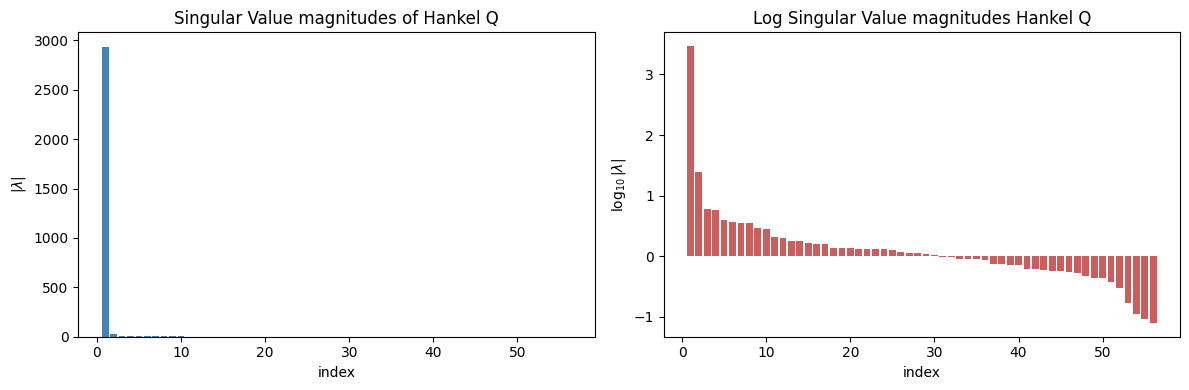

eff_rank: 1, stable_rank: 1.00, spikiness: 1.05, shape: (56, 56), non-zero rows :56, non-zero cols:56
top-r leverage spread: row min=0.01621 max=0.01899 (uniform 0.01786) | col min=0.01621 max=0.01899 (uniform 0.01786)
coherence score: row=1.064 col=1.064
****************************Hankel V****************************


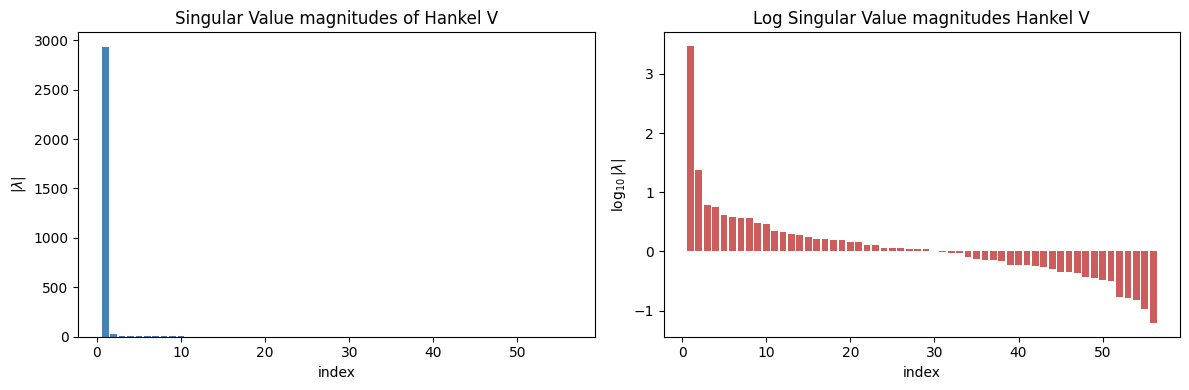

eff_rank: 1, stable_rank: 1.00, spikiness: 1.05, shape: (56, 56), non-zero rows :56, non-zero cols:56
top-r leverage spread: row min=0.01621 max=0.019 (uniform 0.01786) | col min=0.01621 max=0.019 (uniform 0.01786)
coherence score: row=1.064 col=1.064
****************************Q-function****************************


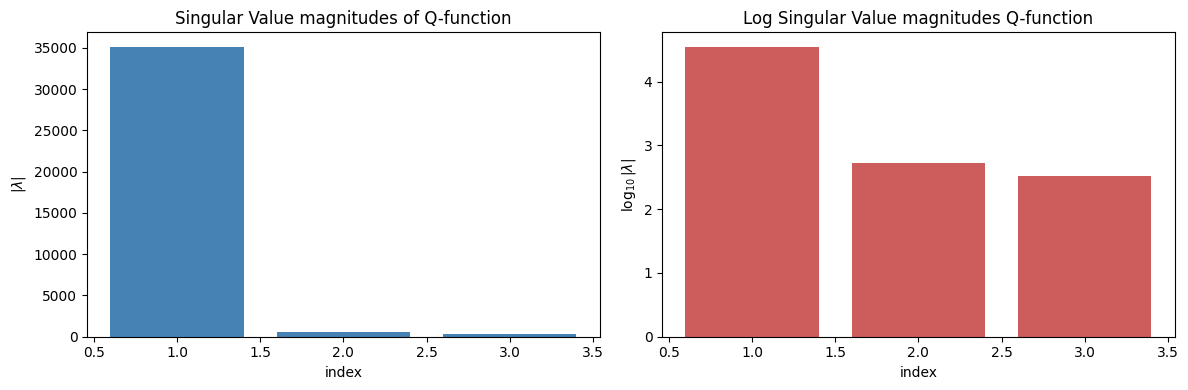

 30%|███       | 151/500 [03:29<10:56,  1.88s/it]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.49, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=3.424e-07 max=8.219e-06 (uniform 3.815e-06) | col min=0.3292 max=0.3363 (uniform 0.3333)
coherence score: row=2.155 col=1.009


 32%|███▏      | 161/500 [03:34<02:57,  1.91it/s]

episode 160 avg_rewarg: -113.9


 34%|███▍      | 171/500 [03:40<03:19,  1.65it/s]

...

episode 180 avg_rewarg: -97.0


 38%|███▊      | 191/500 [03:51<03:01,  1.70it/s]

episode 190 avg_rewarg: -121.1


 40%|████      | 200/500 [03:56<02:46,  1.80it/s]

episode 200 avg_rewarg: -112.3
****************************Hankel Q****************************


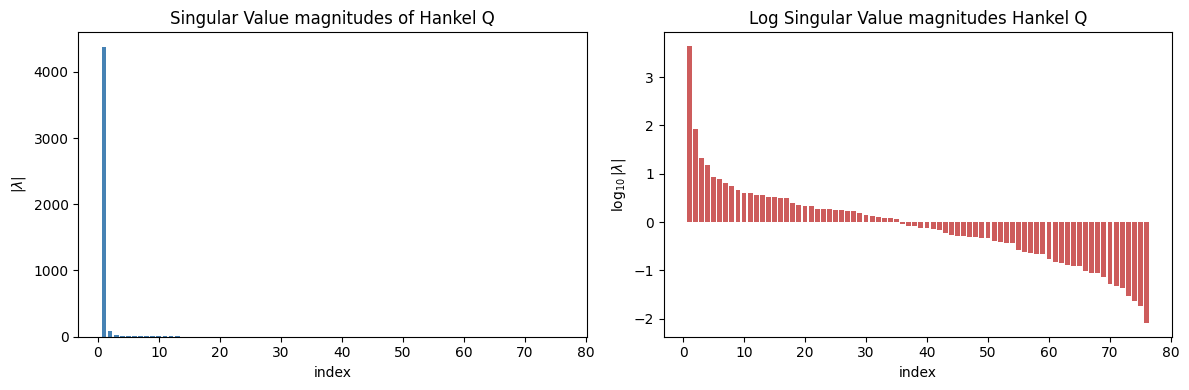

eff_rank: 1, stable_rank: 1.00, spikiness: 1.05, shape: (76, 76), non-zero rows :76, non-zero cols:76
top-r leverage spread: row min=0.01128 max=0.01432 (uniform 0.01316) | col min=0.01128 max=0.01432 (uniform 0.01316)
coherence score: row=1.088 col=1.088
****************************Hankel V****************************


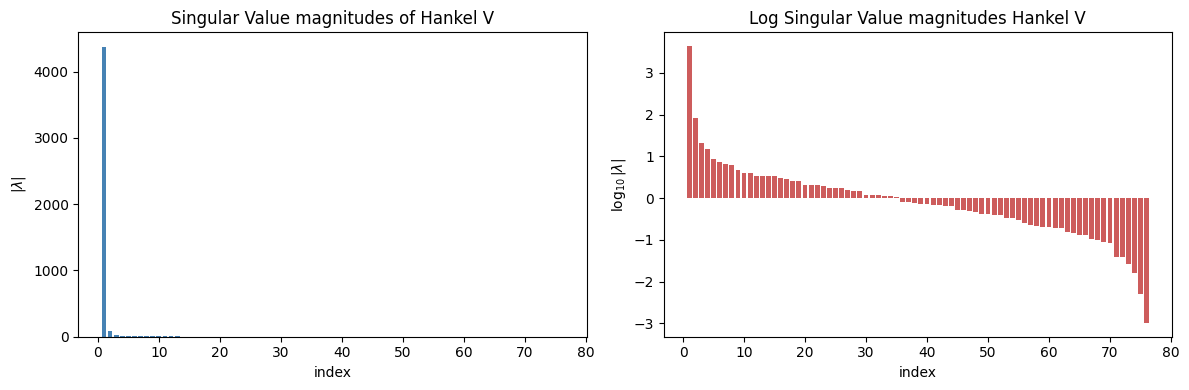

eff_rank: 1, stable_rank: 1.00, spikiness: 1.05, shape: (76, 76), non-zero rows :76, non-zero cols:76
top-r leverage spread: row min=0.01127 max=0.01432 (uniform 0.01316) | col min=0.01127 max=0.01432 (uniform 0.01316)
coherence score: row=1.089 col=1.089
****************************Q-function****************************


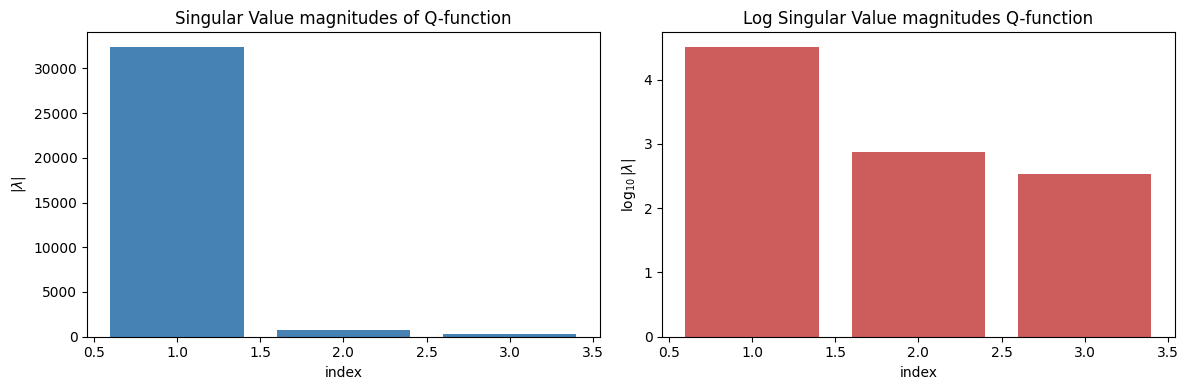

 40%|████      | 201/500 [04:01<09:25,  1.89s/it]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.75, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=5.43e-08 max=1.153e-05 (uniform 3.815e-06) | col min=0.327 max=0.3381 (uniform 0.3333)
coherence score: row=3.024 col=1.014


 42%|████▏     | 211/500 [04:07<02:41,  1.79it/s]

episode 210 avg_rewarg: -111.9


 44%|████▍     | 221/500 [04:12<02:17,  2.03it/s]

...

episode 230 avg_rewarg: -105.6


 48%|████▊     | 241/500 [04:24<02:24,  1.80it/s]

episode 240 avg_rewarg: -108.4


 50%|█████     | 250/500 [04:28<02:09,  1.94it/s]

episode 250 avg_rewarg: -117.5
****************************Hankel Q****************************


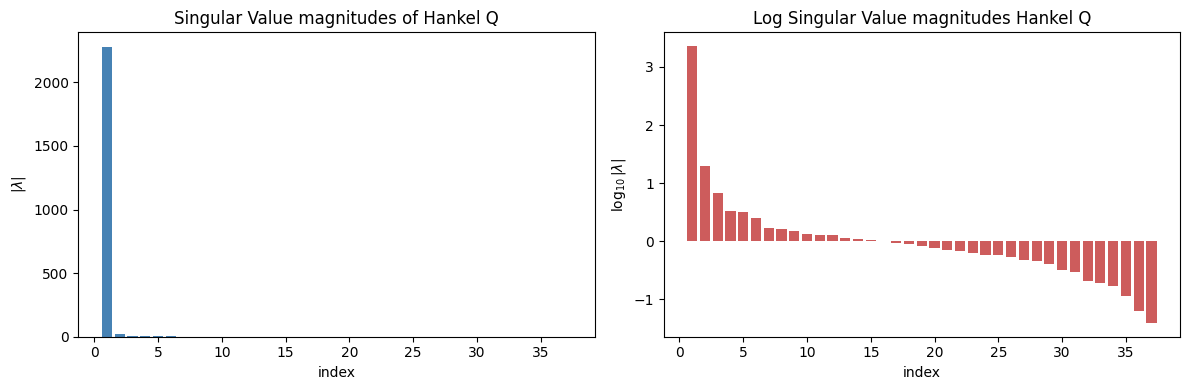

eff_rank: 1, stable_rank: 1.00, spikiness: 1.06, shape: (38, 37), non-zero rows :38, non-zero cols:37
top-r leverage spread: row min=0.02319 max=0.02862 (uniform 0.02632) | col min=0.02392 max=0.02934 (uniform 0.02703)
coherence score: row=1.088 col=1.086
****************************Hankel V****************************


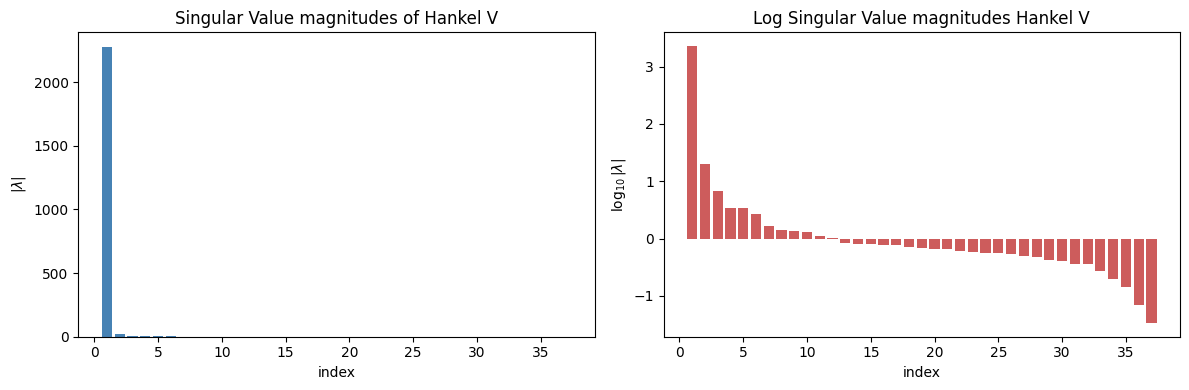

eff_rank: 1, stable_rank: 1.00, spikiness: 1.06, shape: (38, 37), non-zero rows :38, non-zero cols:37
top-r leverage spread: row min=0.02319 max=0.02864 (uniform 0.02632) | col min=0.02391 max=0.02936 (uniform 0.02703)
coherence score: row=1.088 col=1.086
****************************Q-function****************************


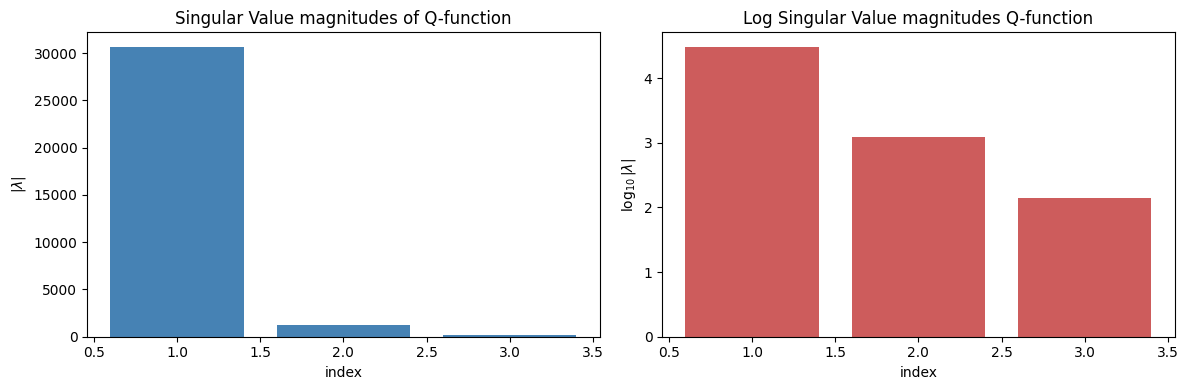

 50%|█████     | 251/500 [04:33<07:40,  1.85s/it]

eff_rank: 1, stable_rank: 1.00, spikiness: 1.97, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=3.447e-15 max=1.472e-05 (uniform 3.815e-06) | col min=0.3216 max=0.3421 (uniform 0.3333)
coherence score: row=3.858 col=1.026


 52%|█████▏    | 261/500 [04:39<02:13,  1.80it/s]

episode 260 avg_rewarg: -100.5


 54%|█████▍    | 271/500 [04:43<01:39,  2.29it/s]

...

episode 280 avg_rewarg: -89.7


 58%|█████▊    | 291/500 [04:53<01:44,  2.00it/s]

episode 290 avg_rewarg: -91.5


 60%|██████    | 300/500 [04:57<01:22,  2.43it/s]

episode 300 avg_rewarg: -90.8
****************************Hankel Q****************************


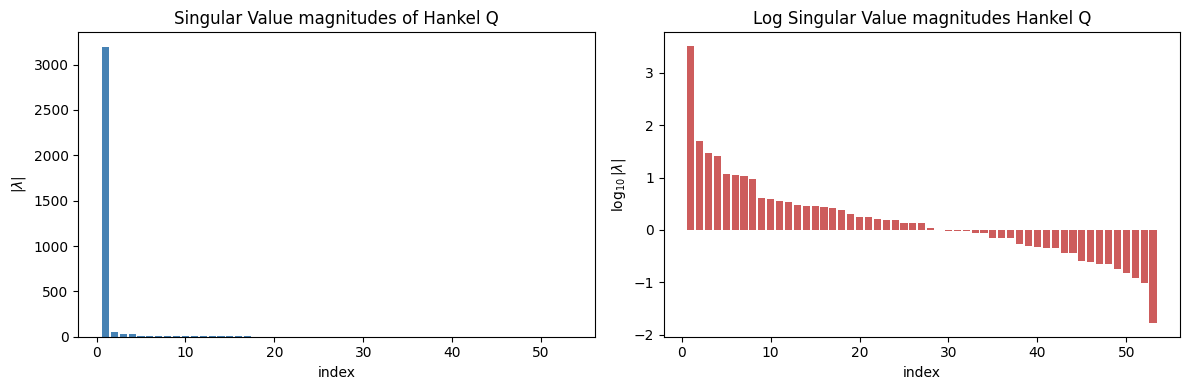

eff_rank: 1, stable_rank: 1.00, spikiness: 1.13, shape: (53, 53), non-zero rows :53, non-zero cols:53
top-r leverage spread: row min=0.01499 max=0.02208 (uniform 0.01887) | col min=0.01499 max=0.02208 (uniform 0.01887)
coherence score: row=1.17 col=1.17
****************************Hankel V****************************


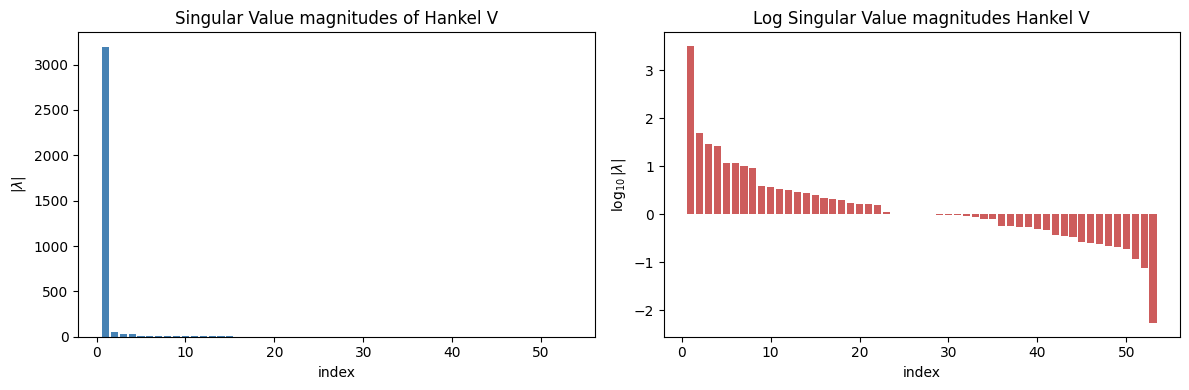

eff_rank: 1, stable_rank: 1.00, spikiness: 1.13, shape: (53, 53), non-zero rows :53, non-zero cols:53
top-r leverage spread: row min=0.01498 max=0.02209 (uniform 0.01887) | col min=0.01498 max=0.02209 (uniform 0.01887)
coherence score: row=1.171 col=1.171
****************************Q-function****************************


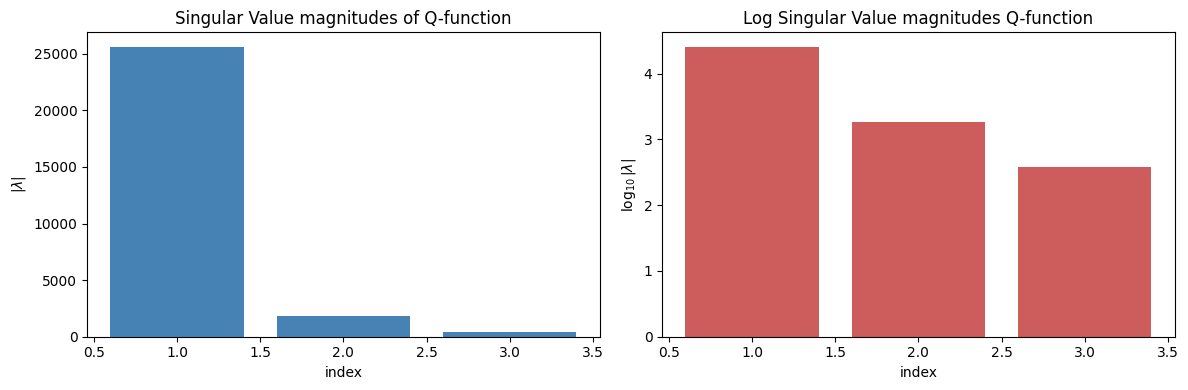

 60%|██████    | 301/500 [05:01<05:25,  1.63s/it]

eff_rank: 1, stable_rank: 1.01, spikiness: 2.44, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=8.348e-17 max=2.272e-05 (uniform 3.815e-06) | col min=0.3189 max=0.3412 (uniform 0.3333)
coherence score: row=5.955 col=1.023


 62%|██████▏   | 311/500 [05:07<01:49,  1.72it/s]

episode 310 avg_rewarg: -93.3


 64%|██████▍   | 321/500 [05:11<01:17,  2.31it/s]

...

episode 330 avg_rewarg: -103.0


 68%|██████▊   | 341/500 [05:20<01:04,  2.48it/s]

episode 340 avg_rewarg: -84.6


 70%|███████   | 350/500 [05:25<01:22,  1.81it/s]

episode 350 avg_rewarg: -90.3
****************************Hankel Q****************************


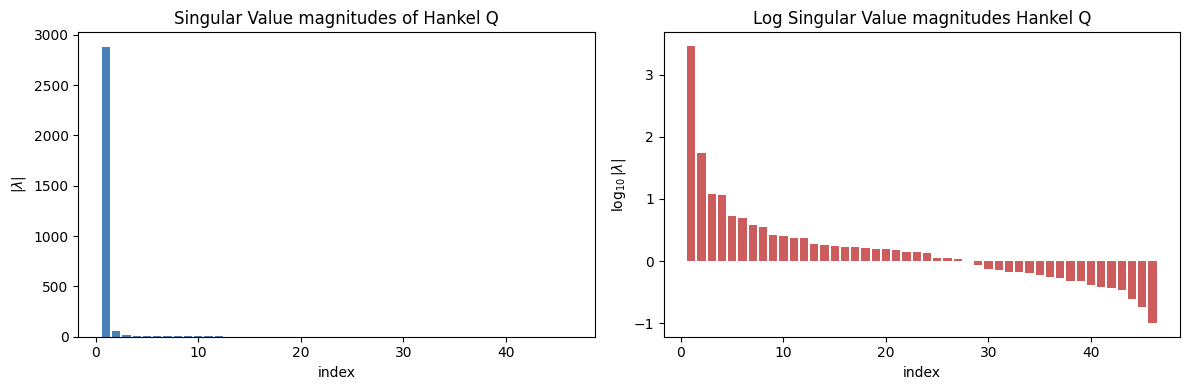

eff_rank: 1, stable_rank: 1.00, spikiness: 1.14, shape: (47, 46), non-zero rows :47, non-zero cols:46
top-r leverage spread: row min=0.01654 max=0.02514 (uniform 0.02128) | col min=0.01702 max=0.02562 (uniform 0.02174)
coherence score: row=1.182 col=1.178
****************************Hankel V****************************


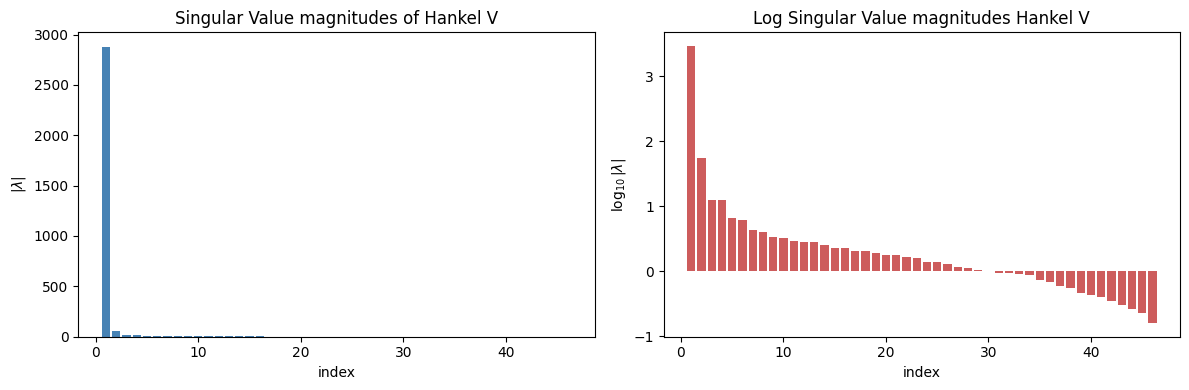

eff_rank: 1, stable_rank: 1.00, spikiness: 1.14, shape: (47, 46), non-zero rows :47, non-zero cols:46
top-r leverage spread: row min=0.01652 max=0.02516 (uniform 0.02128) | col min=0.017 max=0.02563 (uniform 0.02174)
coherence score: row=1.182 col=1.179
****************************Q-function****************************


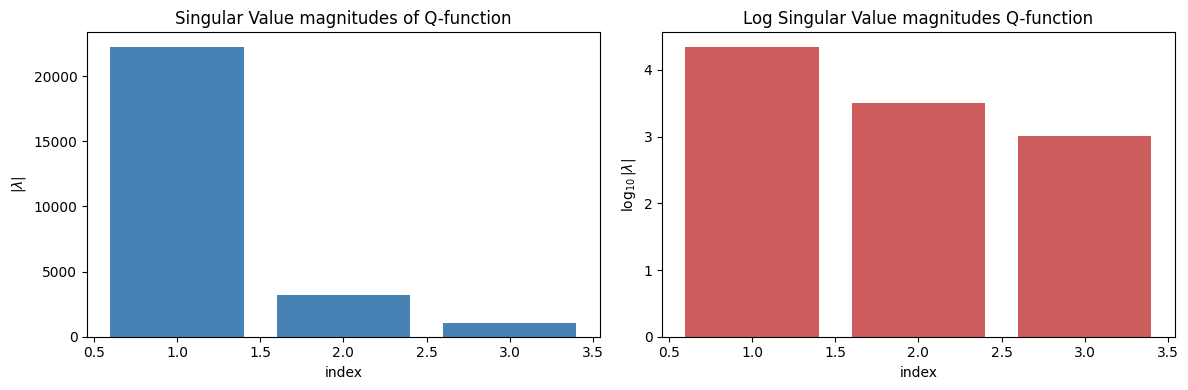

 70%|███████   | 351/500 [05:30<04:15,  1.71s/it]

eff_rank: 1, stable_rank: 1.02, spikiness: 3.11, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=3.771e-16 max=3.187e-05 (uniform 3.815e-06) | col min=0.2853 max=0.3936 (uniform 0.3333)
coherence score: row=8.355 col=1.181


 72%|███████▏  | 361/500 [05:34<00:58,  2.38it/s]

episode 360 avg_rewarg: -82.4


 74%|███████▍  | 371/500 [05:38<00:45,  2.81it/s]

...

episode 380 avg_rewarg: -91.1


 78%|███████▊  | 391/500 [05:48<00:45,  2.38it/s]

episode 390 avg_rewarg: -88.1


 80%|████████  | 400/500 [05:52<00:53,  1.85it/s]

episode 400 avg_rewarg: -101.8
****************************Hankel Q****************************


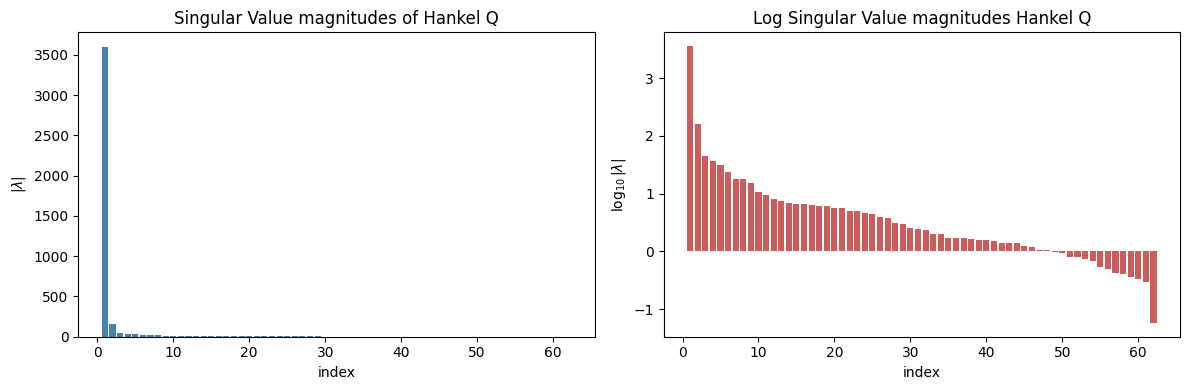

eff_rank: 1, stable_rank: 1.00, spikiness: 1.24, shape: (62, 62), non-zero rows :62, non-zero cols:62
top-r leverage spread: row min=0.009667 max=0.02143 (uniform 0.01613) | col min=0.009667 max=0.02143 (uniform 0.01613)
coherence score: row=1.329 col=1.329
****************************Hankel V****************************


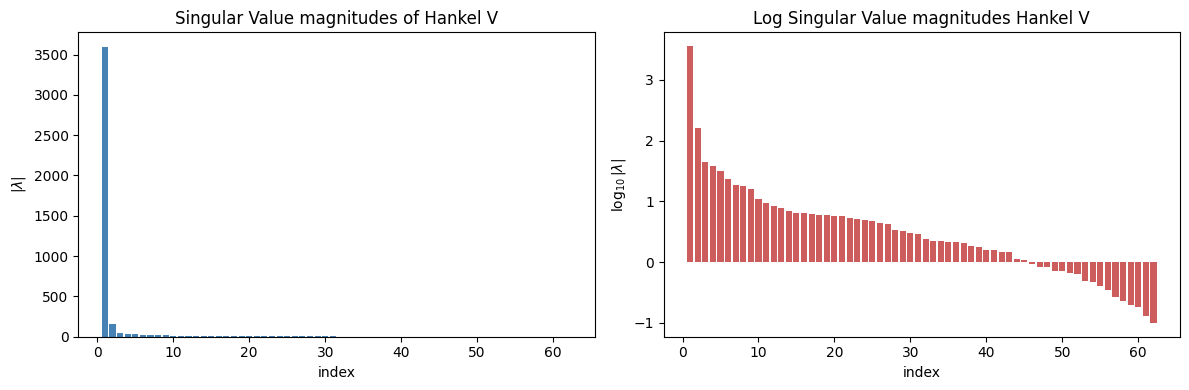

eff_rank: 1, stable_rank: 1.00, spikiness: 1.24, shape: (62, 62), non-zero rows :62, non-zero cols:62
top-r leverage spread: row min=0.009667 max=0.02145 (uniform 0.01613) | col min=0.009667 max=0.02145 (uniform 0.01613)
coherence score: row=1.33 col=1.33
****************************Q-function****************************


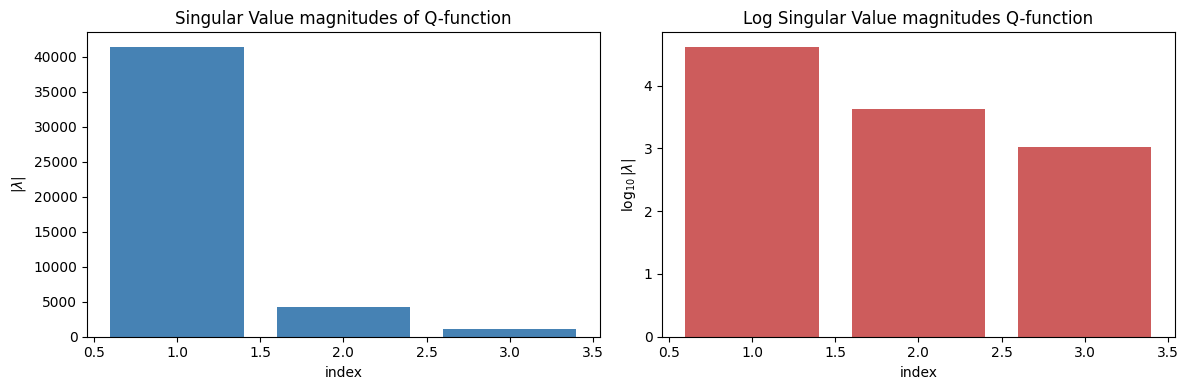

 80%|████████  | 401/500 [05:57<02:58,  1.81s/it]

eff_rank: 1, stable_rank: 1.01, spikiness: 3.31, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=1.959e-16 max=3.646e-05 (uniform 3.815e-06) | col min=0.2966 max=0.3852 (uniform 0.3333)
coherence score: row=9.557 col=1.156


 82%|████████▏ | 411/500 [06:02<00:47,  1.87it/s]

episode 410 avg_rewarg: -91.1


 84%|████████▍ | 421/500 [06:06<00:36,  2.15it/s]

...

episode 430 avg_rewarg: -86.8


 88%|████████▊ | 441/500 [06:16<00:30,  1.92it/s]

episode 440 avg_rewarg: -89.6


 90%|█████████ | 450/500 [06:20<00:22,  2.20it/s]

episode 450 avg_rewarg: -101.8
****************************Hankel Q****************************


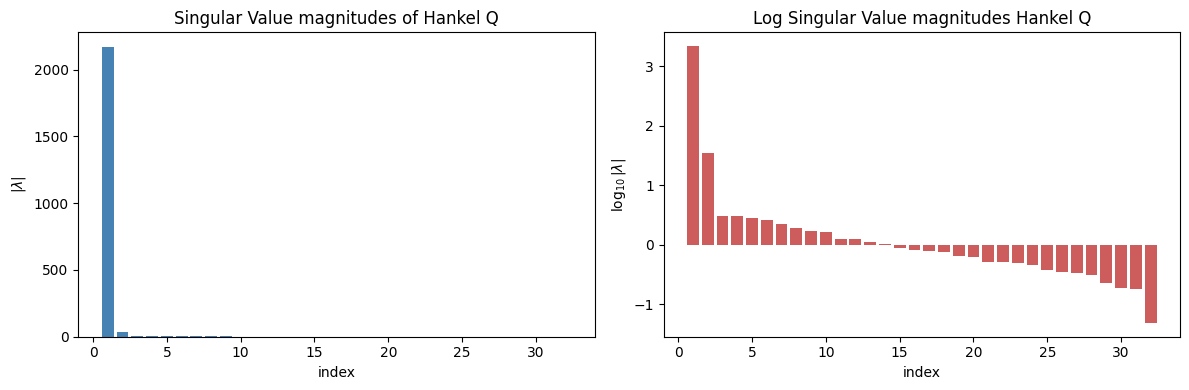

eff_rank: 1, stable_rank: 1.00, spikiness: 1.11, shape: (33, 32), non-zero rows :33, non-zero cols:32
top-r leverage spread: row min=0.02474 max=0.03459 (uniform 0.0303) | col min=0.02571 max=0.03556 (uniform 0.03125)
coherence score: row=1.141 col=1.138
****************************Hankel V****************************


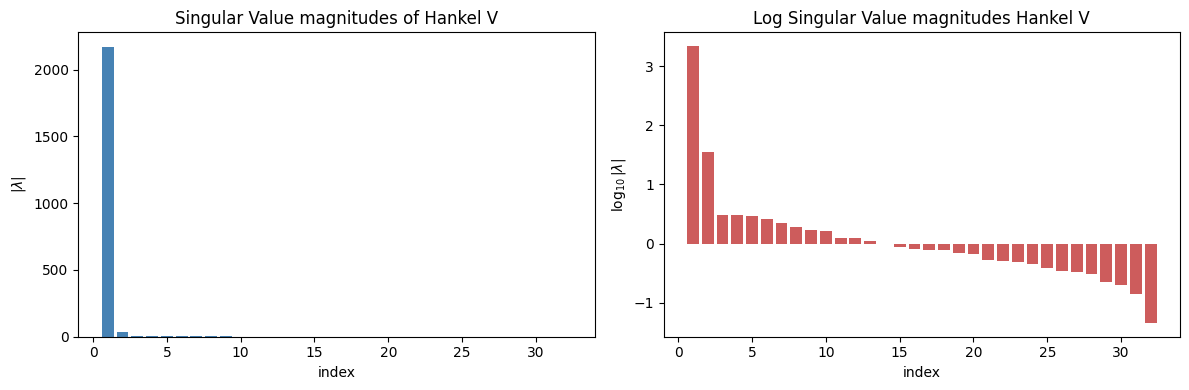

eff_rank: 1, stable_rank: 1.00, spikiness: 1.11, shape: (33, 32), non-zero rows :33, non-zero cols:32
top-r leverage spread: row min=0.02474 max=0.03458 (uniform 0.0303) | col min=0.02571 max=0.03556 (uniform 0.03125)
coherence score: row=1.141 col=1.138
****************************Q-function****************************


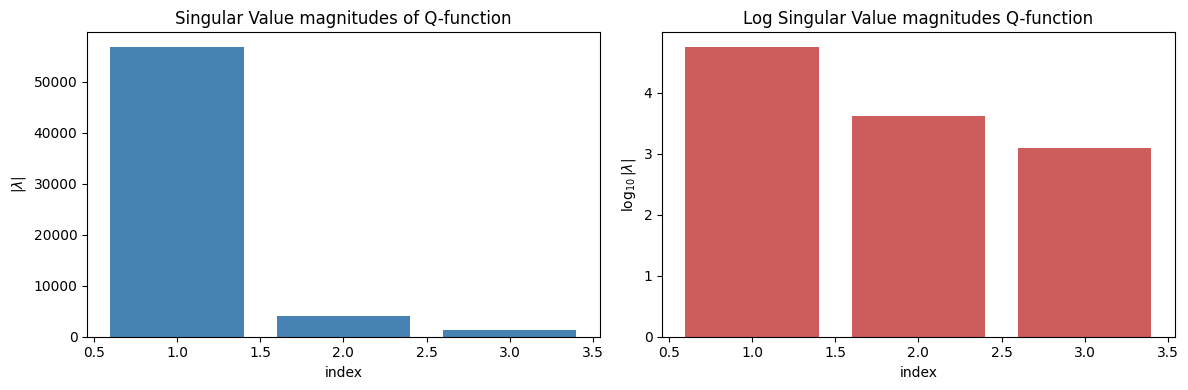

 90%|█████████ | 451/500 [06:25<01:18,  1.61s/it]

eff_rank: 1, stable_rank: 1.01, spikiness: 2.83, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=6.514e-17 max=2.994e-05 (uniform 3.815e-06) | col min=0.3217 max=0.3396 (uniform 0.3333)
coherence score: row=7.847 col=1.019


 92%|█████████▏| 461/500 [06:29<00:19,  1.99it/s]

episode 460 avg_rewarg: -82.6


 94%|█████████▍| 471/500 [06:34<00:13,  2.08it/s]

...

 96%|█████████▌| 481/500 [06:38<00:07,  2.39it/s]

episode 480 avg_rewarg: -85.6


 98%|█████████▊| 491/500 [06:43<00:03,  2.57it/s]

episode 490 avg_rewarg: -91.4


100%|██████████| 500/500 [06:47<00:00,  1.23it/s]


In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps=t["train_frequency_steps"],
    use_episode_training=t["use_episode_training"],
    solved_reward=t["solved_reward"],
    warmup_steps=t["warmup_steps"],
    early_stopping_patience_eps=t["early_stopping_patience_eps"],
    no_eps_to_avg=t["no_eps_to_avg"],
    np_seed=seed,
    analysis_config=analysis,
    
)

## Training and Analysis Plots (now with pi*(theeta))

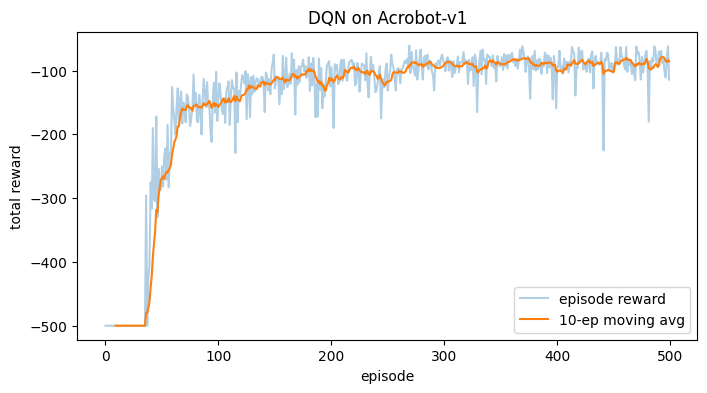

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend(); plt.show()

Hankel Q


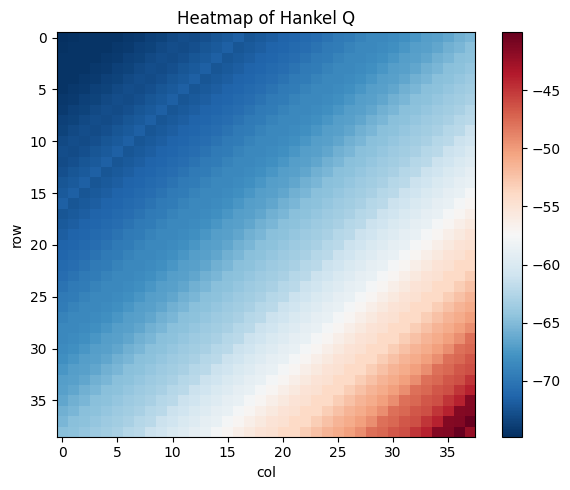

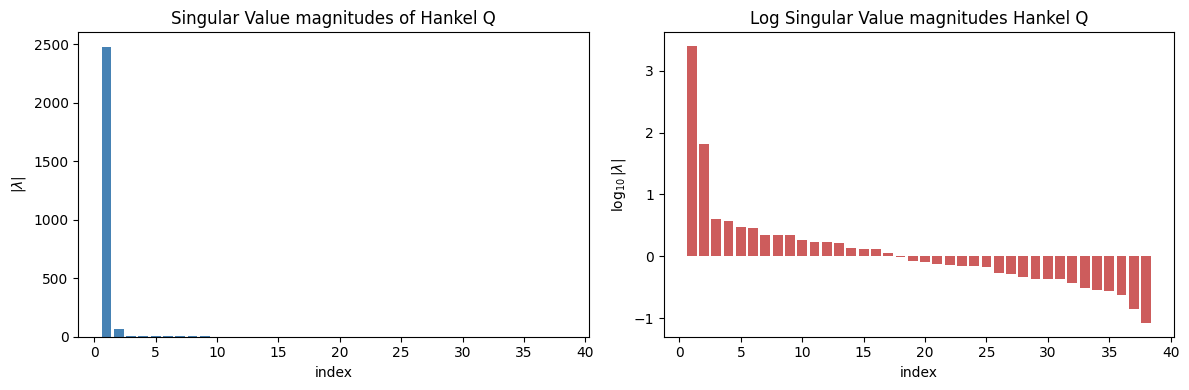

eff_rank: 1, stable_rank: 1.00, spikiness: 1.16, shape: (39, 38), non-zero rows :39, non-zero cols:38
top-r leverage spread: row min=0.01851 max=0.03132 (uniform 0.02564) | col min=0.0192 max=0.032 (uniform 0.02632)
coherence score: row=1.221 col=1.216
Hankel V


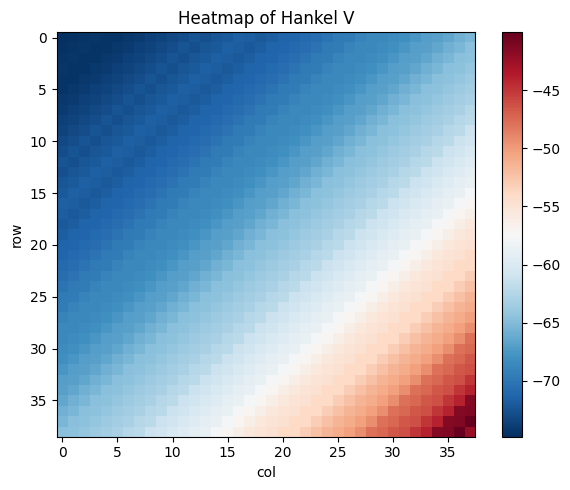

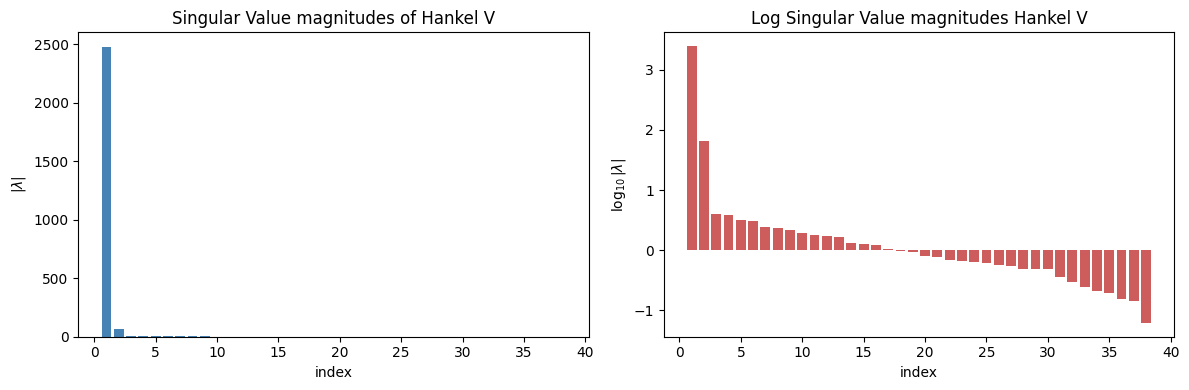

eff_rank: 1, stable_rank: 1.00, spikiness: 1.16, shape: (39, 38), non-zero rows :39, non-zero cols:38
top-r leverage spread: row min=0.01851 max=0.0313 (uniform 0.02564) | col min=0.01921 max=0.03199 (uniform 0.02632)
coherence score: row=1.221 col=1.215
Q-function


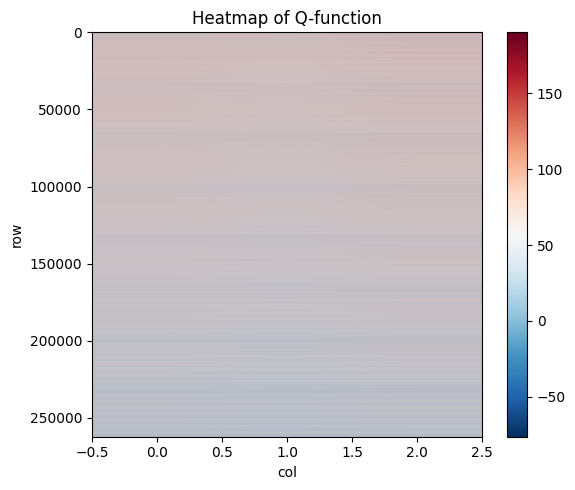

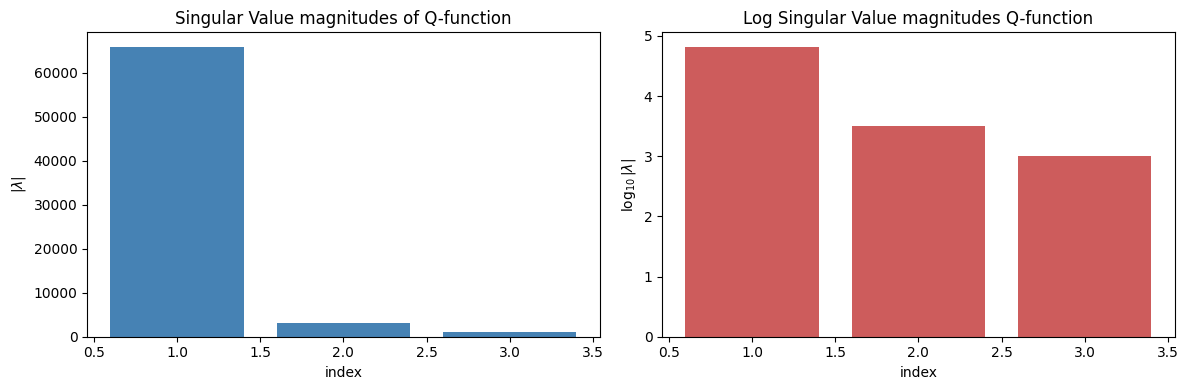

eff_rank: 1, stable_rank: 1.00, spikiness: 2.56, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=9.794e-17 max=2.48e-05 (uniform 3.815e-06) | col min=0.3225 max=0.3421 (uniform 0.3333)
coherence score: row=6.502 col=1.026


In [9]:
for method, names in analysis["methods"]:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained `agent` and display it inline. The eval env is rebuilt with `render_mode="rgb_array"` so frames can be captured.

In [ ]:
# Greedy rollout video of the trained agent
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = make_environment(
    env_cfg["name"],
    render_mode="rgb_array",
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
)
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=seed)
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)